<a href="https://colab.research.google.com/github/peulearning/notebooks_tcc/blob/main/Archiceture_Sequencial_3_Classes_Modify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo / Sistema de Classificação de Feridas – Rede CNN Sequencial Simples

### Bacharelado em Sistemas de Informações

#### IFNMG Campus Januária

---

### Orientador: Drº Mr. Prof. Felipe Augusto Oliveira Mota  
### Co-orientadora: Mr. Profª Suzana Vieira Mota  
### Discente: Pedro Henrique Araújo Mattos Ribeiro

---

## Estudo da Implementação de uma Rede Convolucional Sequencial Simples
### Classificação de Imagens de Feridas e Lesões Cutâneas


# Classificação de Feridas Cutâneas com Rede CNN Sequencial Simples 🧠📸

Neste notebook, iremos aplicar uma **Rede Neural Convolucional (CNN) Sequencial Simples**, desenvolvida especificamente para a tarefa de **classificação de feridas cutâneas**, utilizando uma arquitetura enxuta, eficiente e adequada para implementação em dispositivos móveis.

O objetivo é:
- Classificar imagens de feridas em **categorias específicas** (ex.: úlcera, lesão infecciosa, ferida cirúrgica, pele saudável);
- Comparar o desempenho com arquiteturas mais robustas vistas posteriormente (como MobileNetV2 ou YOLO);
- Demonstrar que **modelos simples e leves** podem alcançar bons resultados em datasets médios.

---

## O que é uma CNN Sequencial?

Uma **CNN Sequencial** é um modelo construído camada por camada, onde cada camada recebe como entrada a saída da camada anterior.  
É o tipo mais simples de arquitetura convolucional disponível no Keras, ideal para:

- iniciantes em visão computacional,
- experimentos exploratórios,
- aplicações com **baixo custo computacional**, como inferência em smartphone via TensorFlow Lite.

### Principais características da arquitetura usada:

- **Camadas Conv2D** para extração de características (bordas, texturas, padrões de cor);
- **Camadas MaxPooling2D** para reduzir dimensionalidade e evitar overfitting;
- **Flatten + Dense** para interpretar as características aprendidas;
- **Dropout** para regularização;
- **Softmax** para classificação final multiclasse.

Essa abordagem oferece uma excelente introdução à **classificação de imagens**, permitindo entender como CNNs funcionam antes de migrar para modelos mais avançados.

---

## Por que usar uma CNN Sequencial Simples?

Apesar de ser menos complexa que modelos grandes como MobileNet ou ResNet, uma CNN sequencial bem configurada pode:

- alcançar boa acurácia com **datasets balanceados**,  
- ser facilmente convertida para **TensorFlow Lite**,  
- executar de forma eficiente em **smartphones**,  
- permitir maior controle sobre cada camada da arquitetura.

Isso a torna uma opção adequada para aplicações na área da saúde, especialmente em cenários com poucos recursos computacionais.

---

## Estrutura geral do notebook

1. Importação das bibliotecas (TensorFlow/Keras);
2. Carregamento e organização do dataset de feridas;
3. Pré-processamento das imagens (normalização, redimensionamento);
4. Data Augmentation para aumentar a robustez do modelo;
5. Definição da **arquitetura Sequencial CNN** passo a passo;
6. Treinamento, callbacks e ajuste dos hiperparâmetros;
7. Avaliação (acurácia, perda, matriz de confusão, precisão/recall);
8. Teste do modelo em imagens reais;
9. Conversão opcional para **TensorFlow Lite** para uso em app mobile.

---

💡 **Observação:**  
Este notebook tem como foco demonstrar o **fluxo completo de construção de uma CNN simples**, servindo como base para comparação com modelos mais avançados utilizados posteriormente no TCC.


# - 1. Importações Iniciais

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# - 2. Célula para limpar Imagens do Drive

In [ ]:
import os
import shutil


#Esta célula foi criada com intuito de apagar todas as imagens e diretórios para executar o modelo quantas vezes serem necessárias
# Lista de pastas a serem removidas
pastas_para_remover = [
    "/content/drive/MyDrive/data_wounds",
    "/content/drive/MyDrive/data_big",
    "/content/drive/MyDrive/images_ready",
    "/content/drive/MyDrive/data_split",
    "/content/drive/MyDrive/data_split_reduzido"
]

print("Iniciando a remoção das pastas...")

for pasta in pastas_para_remover:
    if os.path.exists(pasta):
        try:
            shutil.rmtree(pasta)
            print(f"Pasta '{pasta}' removida com sucesso.")
        except OSError as e:
            print(f"Erro ao remover a pasta '{pasta}': {e}")
    else:
        print(f"Pasta '{pasta}' não encontrada.")

print("✅ Limpeza concluída.")

Iniciando a remoção das pastas...
Pasta '/content/drive/MyDrive/data_wounds' não encontrada.
Pasta '/content/drive/MyDrive/data_big' não encontrada.
Pasta '/content/drive/MyDrive/images_ready' não encontrada.
Pasta '/content/drive/MyDrive/data_split' não encontrada.
Pasta '/content/drive/MyDrive/data_split_reduzido' não encontrada.
✅ Limpeza concluída.


In [ ]:
import os
import shutil

base_split_dir = "/content/drive/MyDrive/data_split"
bg_folder_name = "BG"

for split in ['train', 'val', 'test']:
    bg_path = os.path.join(base_split_dir, split, bg_folder_name)
    if os.path.exists(bg_path):
        shutil.rmtree(bg_path)
        print(f"Removed '{bg_path}'")
    else:
        print(f"'{bg_path}' not found.")

print("✅ Removal of 'BG' folders complete.")

'/content/drive/MyDrive/data_split/train/BG' not found.
'/content/drive/MyDrive/data_split/val/BG' not found.
'/content/drive/MyDrive/data_split/test/BG' not found.
✅ Removal of 'BG' folders complete.


# - 3. Descompacter o DataSet do artigo ou repositório   https://github.com/uwm-bigdata/wound-classification-using-images-and-locations/tree/main

In [ ]:
# Descompactar
import zipfile
import os

# Caminho do arquivo ZIP
caminho_zip = "/content/drive/MyDrive/wound-classification-using-images-and-locations-main.zip"

# Caminho de destino para descompactar
destino = "/content/drive/MyDrive/extraido"

# Cria a pasta de destino se não existir
os.makedirs(destino, exist_ok=True)

# Verifica se o arquivo ZIP existe antes de tentar descompactar
if os.path.exists(caminho_zip):
    # Descompacta o ZIP
    with zipfile.ZipFile(caminho_zip, 'r') as zip_ref:
        zip_ref.extractall(destino)

    print(f"Arquivos extraídos para: {destino}")
else:
    print(f"Erro: O arquivo ZIP não foi encontrado em: {caminho_zip}")
    print("Por favor, verifique se o arquivo está no Google Drive no caminho especificado.")

Arquivos extraídos para: /content/drive/MyDrive/extraido


In [ ]:
!ls /content/drive/MyDrive

 06_recursividade.gdoc
'1 AVALIAÇÃO CALCULO II.gdoc'
 2021_07_02_15_39_42.mp4
'2°_2021 - PLANEJAMENTO EDIFICAÇÕES - ANP.pdf'
'2a. Atividade 2a. Fontes de Informaçõ.gdoc'
'2. Tabela para orientações de análise de artigos.gdoc'
'3a - Atividade 3a - projeto de pesquisa.gdoc'
'3. Atividade.gdoc'
'4 - Atividade 4.gdoc'
'4 ATVD - FSI .gdoc'
'4º Desafio.docx'
'Activity Transactions.gdoc'
'AE 1.pdf'
'AE 2 (1).pdf'
'AE 2 (2).pdf'
'AE 2.pdf'
'alfabetização digital.pdf'
'Aniversário Roberta.gsheet'
'AOC - SEMIN 3 E 4.gdoc'
'AOC - SEMINÁRIOS.gdoc'
'AOC VII.gdoc'
'Arraia dos Amigos 2025.gsheet'
'Arraia Dos Amigos HMJ 2024   Efetuaram Pagamento.gsheet'
'Arraiá festa junina ilustração colorido amarelo preto convite (3).pdf'
 Athulo.gdoc
'atividade 04.gdoc'
'ATIVIDADE_1 (1).gdoc'
'Atividade  18 01 22.gdoc'
'Atividade 1.gdoc'
 ATIVIDADE_1.gdoc
'ATIVIDADE FUNDAMENTOS DA COMPUTAÇÃO.pdf'
'Atividade II (1).gdoc'
'Atividade II.gdoc'
'Atividade III.gdoc'
'Atividade IV Resolução.gdoc'
'Ati

In [ ]:
# Listar somente pastas da estrutura extraída
for root, dirs, files in os.walk(destino):
    level = root.replace(destino, '').count(os.sep)
    indent = ' ' * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    for d in dirs:
        sub_indent = ' ' * 4 * (level + 1)
        print(f"{sub_indent}{d}/")


extraido/
    wound-classification-using-images-and-locations-main/
    wound-classification-using-images-and-locations-main/
        dataset/
        dataset/
            Test/
            Train/
            Test/
                Test/
                __MACOSX/
                Test/
                    BG/
                    D/
                    N/
                    P/
                    S/
                    V/
                    BG/
                    D/
                    N/
                    P/
                    S/
                    V/
                __MACOSX/
                    Test/
                    Test/
                        BG/
                        D/
                        N/
                        P/
                        S/
                        V/
                        BG/
                        D/
                        N/
                        P/
                        S/
                        V/
            Train/
              

In [ ]:
# Salvar imagen e m um data set organizado para trabalhar melhor /content/base_de_dados_feridas
import os
import shutil

# Caminhos
caminho_base = "/content/drive/MyDrive/data_wounds"
os.makedirs(caminho_base, exist_ok=True)

# Mapeamento das siglas para nomes completos
sigla_para_nome = {
    'BG': 'background',
    'D': 'diabetic',
    'N': 'normal',
    'P': 'pressure',
    'S': 'sirurgical',
    'V': 'venous'
}

# Caminhos das pastas de origem
train_dir = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Train/Train"
test_dir = "/content/drive/MyDrive/extraido/wound-classification-using-images-and-locations-main/dataset/Test/Test"

# Função para copiar as imagens
def copiar_imagens(origem, destino_base, renomear_pasta=False):
    for nome_pasta in os.listdir(origem):
        caminho_origem = os.path.join(origem, nome_pasta)

        if not os.path.isdir(caminho_origem):
            continue

        # Renomeia caso seja pasta de sigla
        if renomear_pasta and nome_pasta in sigla_para_nome:
            nome_final = sigla_para_nome[nome_pasta]
        else:
            nome_final = nome_pasta

        caminho_destino = os.path.join(destino_base, nome_final)
        os.makedirs(caminho_destino, exist_ok=True)

        # Copia os arquivos de imagem
        for nome_arquivo in os.listdir(caminho_origem):
            origem_arquivo = os.path.join(caminho_origem, nome_arquivo)
            destino_arquivo = os.path.join(caminho_destino, nome_arquivo)

            if os.path.isfile(origem_arquivo):
                shutil.copy2(origem_arquivo, destino_arquivo)

# Copiar imagens de Train (sem renomear)
copiar_imagens(train_dir, caminho_base)

# Copiar imagens de Test (renomeando siglas)
copiar_imagens(test_dir, caminho_base, renomear_pasta=True)

print("Imagens unificadas em:", caminho_base)

Imagens unificadas em: /content/drive/MyDrive/data_wounds


In [ ]:
import os

path = "/content/drive/MyDrive/data_wounds"

if os.path.exists(path):
    print(f"Conteúdo da pasta {path}:")
    for item in os.listdir(path):
        print(item)
else:
    print(f"A pasta {path} não foi encontrada.")

Conteúdo da pasta /content/drive/MyDrive/data_wounds:
diabetic
normal
pressure
sirurgical
venous
background


In [ ]:
import shutil
import os

# List of folders to remove from /content/drive/MyDrive/data_wounds
folders_to_remove = [
    "/content/drive/MyDrive/data_wounds/sirurgical",
    "/content/drive/MyDrive/data_wounds/venous",
    "/content/drive/MyDrive/data_wounds/background",
]

print("Iniciando a remoção das pastas indesejadas...")

for pasta in folders_to_remove:
    if os.path.exists(pasta):
        try:
            shutil.rmtree(pasta)
            print(f"Pasta '{os.path.basename(pasta)}' removida com sucesso.")
        except OSError as e:
            print(f"Erro ao remover a pasta '{os.path.basename(pasta)}': {e}")
    else:
        print(f"Pasta '{os.path.basename(pasta)}' não encontrada.")

print("✅ Limpeza concluída.")

Iniciando a remoção das pastas indesejadas...
Pasta 'sirurgical' removida com sucesso.
Pasta 'venous' removida com sucesso.
Pasta 'background' removida com sucesso.
✅ Limpeza concluída.


In [ ]:
# import os
# import shutil

# base_split_dir = "/content/drive/MyDrive/data_split"
# bg_folder_name = "background"

# for split in ['train', 'val', 'test']:
#     bg_path = os.path.join(base_split_dir, split, bg_folder_name)
#     if os.path.exists(bg_path):
#         shutil.rmtree(bg_path)
#         print(f"Removed '{bg_path}'")
#     else:
#         print(f"'{bg_path}' not found.")

# print("✅ Removal of 'BG' folders complete.")

In [ ]:
# contar imagem na pasta da base de dados
import os

# Caminho para a pasta base
base_dir = "/content/drive/MyDrive/data_wounds"

# Inicializar o contador total de imagens
total_images = 0

# Iterar pelas pastas dentro da pasta base
for folder_name in os.listdir(base_dir):
  folder_path = os.path.join(base_dir, folder_name)
  if os.path.isdir(folder_path):  # Verificar se é uma pasta
    image_count = 0
    for filename in os.listdir(folder_path):
      if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')): # Inclui mais extensões de imagem
        image_count += 1
    total_images += image_count
    print(f"Pasta '{folder_name}': {image_count} imagens")

print(f"Total de imagens no dataset: {total_images}")

Pasta 'diabetic': 185 imagens
Pasta 'normal': 100 imagens
Pasta 'pressure': 134 imagens
Total de imagens no dataset: 419


## Aumentando o tamanho do Dataset

In [ ]:
# import os
# import shutil
# #from keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img
# import tensorflow as tf
# from keras.utils import load_img, img_to_array, array_to_img #updated imports
# import numpy as np
# from tqdm import tqdm
# from tensorflow.keras.preprocessing.image import ImageDataGenerator # Import the ImageDataGenerator class


# # Configurações
# CAMINHO_ORIGEM = '/content/drive/MyDrive/data_wounds'
# CAMINHO_DESTINO = '/content/drive/MyDrive/data_big'
# NUM_IMAGENS_DESEJADAS = 900  # Você pode mudar esse valor para 900, etc.
# TAMANHO_IMAGEM = (224, 224)  # Você também pode mudar aqui

# # Aumentos suaves (para manter características das feridas)
# datagen = ImageDataGenerator(
#     rotation_range=10,
#     width_shift_range=0.02,
#     height_shift_range=0.02,
#     zoom_range=0.05,
#     brightness_range=[0.9, 1.1],
#     horizontal_flip=True,
#     fill_mode='nearest'
# )

# # Criar pasta de destino do zero
# if os.path.exists(CAMINHO_DESTINO):
#     shutil.rmtree(CAMINHO_DESTINO)
# os.makedirs(CAMINHO_DESTINO, exist_ok=True)

# # Para cada classe
# for classe in os.listdir(CAMINHO_ORIGEM):
#     pasta_origem = os.path.join(CAMINHO_ORIGEM, classe)
#     pasta_destino = os.path.join(CAMINHO_DESTINO, classe)
#     os.makedirs(pasta_destino, exist_ok=True)

#     imagens_existentes = os.listdir(pasta_origem)
#     total_existente = len(imagens_existentes)

#     print(f"\nClasse '{classe}': {total_existente} imagens existentes.")

#     contador = 0
#     pbar = tqdm(total=NUM_IMAGENS_DESEJADAS, desc=f"Gerando para {classe}")

#     # Copiar imagens originais
#     for nome_img in imagens_existentes:
#         caminho_img = os.path.join(pasta_origem, nome_img)
#         shutil.copy(caminho_img, os.path.join(pasta_destino, nome_img))
#         contador += 1
#         pbar.update(1)
#         if contador >= NUM_IMAGENS_DESEJADAS:
#             break

#     # Se ainda não atingiu a quantidade desejada, gerar aumentadas
#     while contador < NUM_IMAGENS_DESEJADAS:
#         for nome_img in imagens_existentes:
#             img_path = os.path.join(pasta_origem, nome_img)
#             img = load_img(img_path, target_size=TAMANHO_IMAGEM)
#             x = img_to_array(img)
#             x = x.reshape((1,) + x.shape)

#             # Gerar apenas uma imagem aumentada por vez
#             for batch in datagen.flow(x, batch_size=1):
#                 img_aumentada = array_to_img(batch[0])
#                 nome_arquivo = f"aumentada_{contador}_{nome_img}"
#                 img_aumentada.save(os.path.join(pasta_destino, nome_arquivo))
#                 contador += 1
#                 pbar.update(1)
#                 break  # Apenas uma imagem por iteração
#             if contador >= NUM_IMAGENS_DESEJADAS:
#                 break
#     pbar.close()

# print("\n✅ Aumento de dados concluído com sucesso!")

In [ ]:
# contar imagem na pasta da base de dados

import os

# Caminho para a pasta base
base_dir = "/content/drive/MyDrive/data_wounds"

# Inicializar o contador total de imagens
total_images = 0

# Iterar pelas pastas dentro da pasta base
for folder_name in os.listdir(base_dir):
  folder_path = os.path.join(base_dir, folder_name)
  if os.path.isdir(folder_path):  # Verificar se é uma pasta
    image_count = 0
    for filename in os.listdir(folder_path):
      if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')): # Inclui mais extensões de imagem
        image_count += 1
    total_images += image_count
    print(f"Pasta '{folder_name}': {image_count} imagens")

print(f"Total de imagens no dataset: {total_images}")


Pasta 'diabetic': 185 imagens
Pasta 'normal': 100 imagens
Pasta 'pressure': 134 imagens
Total de imagens no dataset: 419


#- 4. Pre processamento e Normalização para preparar o Dataset para Treinamento


In [ ]:
import os
from PIL import Image
import shutil

# Caminho da base original
CAMINHO_ORIGINAL = "/content/drive/MyDrive/data_wounds"
# Caminho para salvar imagens processadas
CAMINHO_SAIDA = "/content/drive/MyDrive/images_ready"
# Tamanho desejado
TAMANHO = (224, 224)

# Cria a pasta de saída se não existir
os.makedirs(CAMINHO_SAIDA, exist_ok=True)

# Loop pelas classes (pastas)
for classe in os.listdir(CAMINHO_ORIGINAL):
    pasta_classe_origem = os.path.join(CAMINHO_ORIGINAL, classe)
    pasta_classe_saida = os.path.join(CAMINHO_SAIDA, classe)

    if not os.path.isdir(pasta_classe_origem):
        continue

    os.makedirs(pasta_classe_saida, exist_ok=True)

    # Loop pelas imagens da classe
    for nome_arquivo in os.listdir(pasta_classe_origem):
        caminho_imagem = os.path.join(pasta_classe_origem, nome_arquivo)

        try:
            img = Image.open(caminho_imagem)

            # Converter para RGB se não for
            if img.mode != 'RGB':
                img = img.convert('RGB')

            # Redimensionar
            img = img.resize(TAMANHO)

            # Salvar imagem processada
            caminho_saida = os.path.join(pasta_classe_saida, nome_arquivo)
            img.save(caminho_saida)

        except Exception as e:
            print(f"Erro ao processar {caminho_imagem}: {e}")


#- 5. Separando conjuto de TESTE / TREINAMENTO / VALIDAÇÃO

In [ ]:
import os
import shutil
import random

# Caminho do dataset original
origem = "/content/drive/MyDrive/data_wounds"

# Novo caminho para os dados divididos
destino_base = "/content/drive/MyDrive/data_split"

# Proporções
train_split = 0.7
val_split = 0.15
test_split = 0.15

# Garante que os diretórios existem
os.makedirs(destino_base, exist_ok=True)
for split in ['train', 'val', 'test']:
    for classe in os.listdir(origem):
        os.makedirs(os.path.join(destino_base, split, classe), exist_ok=True)

# Loop pelas classes
for classe in os.listdir(origem):
    caminho_classe = os.path.join(origem, classe)
    imagens = os.listdir(caminho_classe)
    random.shuffle(imagens)

    total = len(imagens)
    n_train = int(train_split * total)
    n_val = int(val_split * total)

    train_imgs = imagens[:n_train]
    val_imgs = imagens[n_train:n_train + n_val]
    test_imgs = imagens[n_train + n_val:]

    for nome_img in train_imgs:
        shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'train', classe))

    for nome_img in val_imgs:
        shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'val', classe))

    for nome_img in test_imgs:
        shutil.copy(os.path.join(caminho_classe, nome_img), os.path.join(destino_base, 'test', classe))

print("✅ Imagens separadas em treino, validação e teste!")


✅ Imagens separadas em treino, validação e teste!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.02,
    height_shift_range=0.02,
    zoom_range=0.05,
    brightness_range=[0.9, 1.1],
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    "/content/drive/MyDrive/data_split/train", target_size=(224, 224), batch_size=32, class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/data_split/val", target_size=(224, 224), batch_size=32, class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    "/content/drive/MyDrive/data_split/test", target_size=(224, 224), batch_size=32, class_mode='categorical', shuffle=False
)

Found 292 images belonging to 3 classes.
Found 62 images belonging to 3 classes.
Found 65 images belonging to 3 classes.


#- 6. Rede Convolucional / Arquiterura Sequencial ( Modelo )

In [ ]:
from tensorflow.keras import layers, models

modelo = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')  # Changed to 3 classes
])

modelo.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

modelo.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print(train_generator.class_indices)

{'diabetic': 0, 'normal': 1, 'pressure': 2}


In [ ]:
# Treinamento
historico = modelo.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 4s/step - accuracy: 0.3801 - loss: 0.9266 - val_accuracy: 0.4194 - val_loss: 0.6156
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.4452 - loss: 0.6033 - val_accuracy: 0.6129 - val_loss: 0.5861
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.5651 - loss: 0.5397 - val_accuracy: 0.5806 - val_loss: 0.5374
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.6473 - loss: 0.4739 - val_accuracy: 0.6774 - val_loss: 0.4952
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.6370 - loss: 0.4721 - val_accuracy: 0.6290 - val_loss: 0.5283
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - accuracy: 0.7123 - loss: 0.3990 - val_accuracy: 0.7419 - val_loss: 0.4456
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - accuracy: 0.7363 - loss: 0.3748 - val_accuracy: 0.7903 - val_loss: 0.3911
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - accuracy: 0.7500 - loss: 0.3494 - val_accuracy: 0.7097 - val_loss:

#- 7. Avaliação do Modelo com Métricas

In [ ]:
resultado = modelo.evaluate(test_generator)
print(f"Acurácia no conjunto de teste: {resultado[1]*100:.2f}%")


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 329ms/step - accuracy: 0.7538 - loss: 0.5195
Acurácia no conjunto de teste: 75.38%


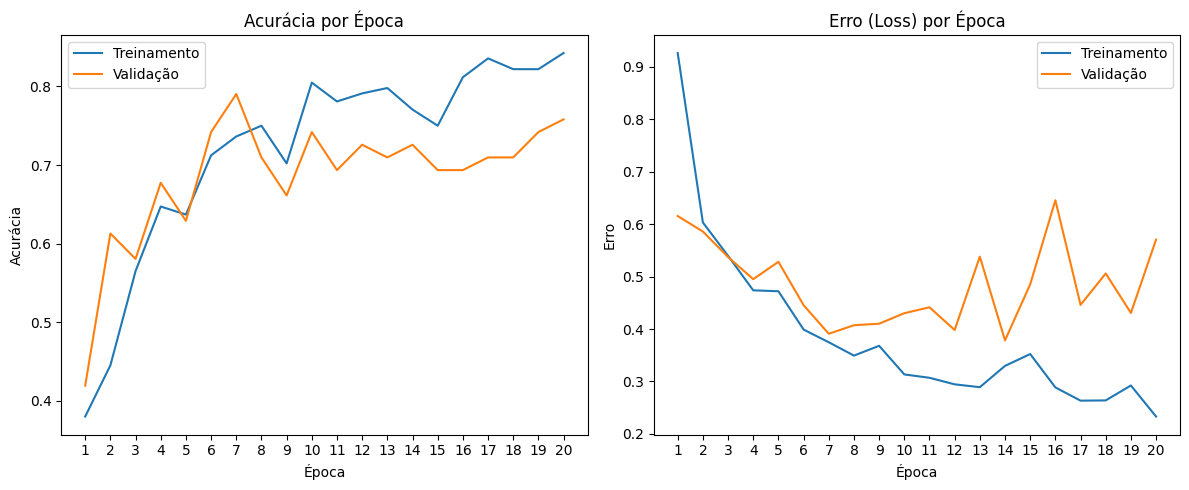

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# 1. Plotar gráfico de acurácia e perda
def plot_history(history):
    # Criar eixo de épocas corretamente (1 até N)
    epochs = np.arange(1, len(history.history['accuracy']) + 1)

    plt.figure(figsize=(12, 5))

    # Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['accuracy'], label='Treinamento')
    plt.plot(epochs, history.history['val_accuracy'], label='Validação')
    plt.title('Acurácia por Época')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.xticks(epochs)  # força valores inteiros no eixo X
    plt.legend()

    # Perda
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['loss'], label='Treinamento')
    plt.plot(epochs, history.history['val_loss'], label='Validação')
    plt.title('Erro (Loss) por Época')
    plt.xlabel('Época')
    plt.ylabel('Erro')
    plt.xticks(epochs)  # força valores inteiros no eixo X
    plt.legend()

    plt.tight_layout()
    plt.show()

# Chamada da função
plot_history(historico)

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step


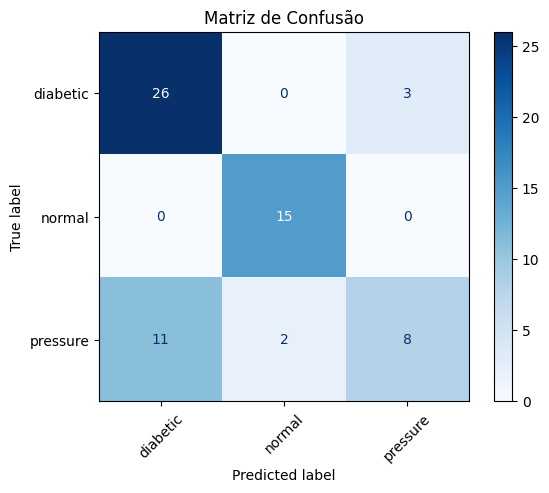


📊 Relatório de Classificação (Precisão, Recall, F1-Score):

              precision    recall  f1-score   support

    diabetic       0.70      0.90      0.79        29
      normal       0.88      1.00      0.94        15
    pressure       0.73      0.38      0.50        21

    accuracy                           0.75        65
   macro avg       0.77      0.76      0.74        65
weighted avg       0.75      0.75      0.73        65



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Pegar os verdadeiros e predições
y_true = test_generator.classes
y_pred_probs = modelo.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Definir a ordem desejada das classes (Background em primeiro)
# Mapeamento: {'background': 0, 'diabetic': 1, 'normal': 2, 'pressure': 3}
ordered_class_names = ['diabetic', 'normal', 'pressure']
ordered_labels = [test_generator.class_indices[name] for name in ordered_class_names]


# Matriz de confusão com a ordem desejada
cm = confusion_matrix(y_true, y_pred, labels=ordered_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ordered_class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão")
plt.xticks(rotation=45)
plt.show()

# Classification report com a ordem desejada
report = classification_report(y_true, y_pred, target_names=ordered_class_names)
print("\n📊 Relatório de Classificação (Precisão, Recall, F1-Score):\n")
print(report)

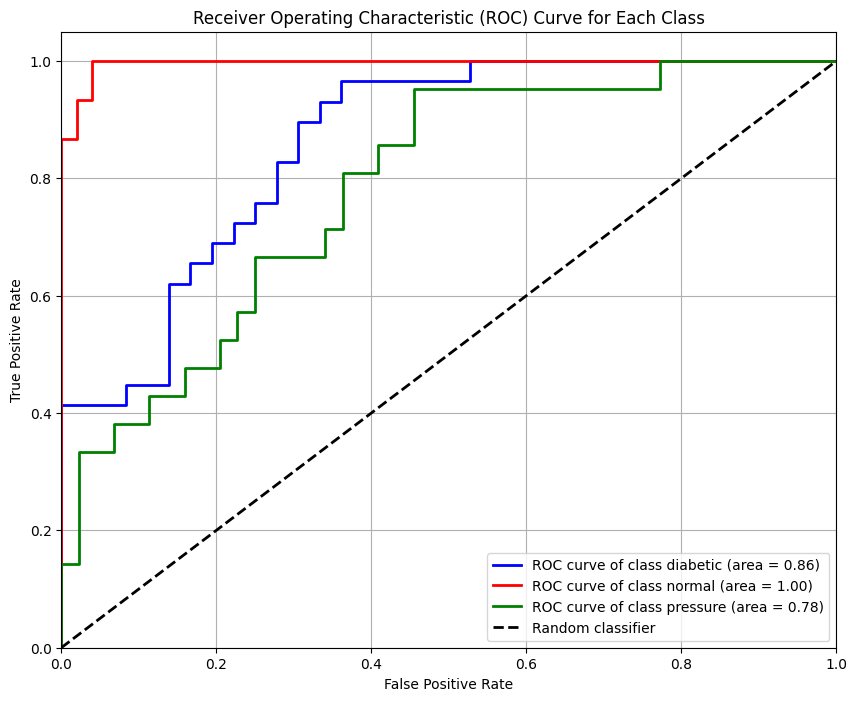

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Assuming y_true and y_pred_probs are already available from previous cells
# y_true = test_generator.classes
# y_pred_probs = modelo.predict(test_generator)

# Get class names from the test generator
class_names = list(test_generator.class_indices.keys())

n_classes = len(class_names)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    # For binary classification (2 classes), y_true is not one-hot encoded.
    # We need to binarize it for each class comparison.
    # y_true_binarized will be 1 where y_true == i, and 0 otherwise
    y_true_binarized = (y_true == i).astype(int)
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized, y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green', 'purple'] # Define colors for each class, adjusted for 4 classes
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Each Class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#- 8. Salvando o MODELO

In [ ]:
# modelo.save('/content/drive/MyDrive/sequencial_feridas_2class.h5')
# print("✅ Modelo salvo com sucesso!")

#- 13. Salvando o Modelo (TensorflowLite) / Excel

In [ ]:
# import tensorflow as tf
# import os

# # 1. Load the Keras model
# keras_model_path = "/content/drive/MyDrive/sequencial_feridas_2class.h5"
# model = tf.keras.models.load_model(keras_model_path)

# # 2. Initialize a TensorFlow Lite converter
# converter = tf.lite.TFLiteConverter.from_keras_model(model)

# # 3. Convert the model
# tflite_model = converter.convert()

# # 4. Save the converted TensorFlow Lite model
# tflite_model_path = "/content/drive/MyDrive/modelo_seq_2_classes.tflite"
# with open(tflite_model_path, 'wb') as f:
#     f.write(tflite_model)

# print(f"✅ Keras model '{os.path.basename(keras_model_path)}' successfully converted and saved as '{os.path.basename(tflite_model_path)}'")

In [ ]:
# import tensorflow as tf
# import os

# # 1. Load the Keras model
# keras_model_path = "/content/drive/MyDrive/sequencial_feridas_2class.h5"
# model = tf.keras.models.load_model(keras_model_path)

# # 2. Initialize a TensorFlow Lite converter
# converter = tf.lite.TFLiteConverter.from_keras_model(model)

# # 3. Convert the model
# tflite_model = converter.convert()

# # 4. Save the converted TensorFlow Lite model
# tflite_model_path = "/content/drive/MyDrive/modelo_seq_2_classes.tflite"
# with open(tflite_model_path, 'wb') as f:
#     f.write(tflite_model)

# print(f"✅ Keras model '{os.path.basename(keras_model_path)}' successfully converted and saved as '{os.path.basename(tflite_model_path)}'")

In [ ]:
# print("The prediction report for both models is saved at: /content/drive/MyDrive/resultados_modelos_2classes.xlsx")